In [ ]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from ddpm_lib.data_loaders import get_nifty_regime_data,prepare_dataloaders,compute_regime_score
from ddpm_lib.models import f_net,FiLMLayer
from ddpm_lib.noisify_time_emb import cosine_beta_scheduler,noisify
from ddpm_lib.diffusion_utils import FiLMTabularDDPM
from ddpm_lib.samplers import sample_n_samples,sample_with_conditions

c:\Users\GARVIT\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
risk_df = get_nifty_regime_data()
risk_df['regime_score'] = compute_regime_score(risk_df)
risk_df['regime_score'] = risk_df['regime_score'].fillna(0.5)
risk_df['regime'] = (risk_df['regime_score'] > 0.5).astype(int)

train_dl, val_dl, condition_df, scaler_x, scaler_cond,val_df = prepare_dataloaders(
    risk_df,
    batch_size=64,
    train_size=0.80,
    val_size=0.10
)

print(f"\nDataLoader batch info:")
print(f"  Train batches: {len(train_dl)}")
print(f"  Validation batches: {len(val_dl)}")
print(f"\nConditioning dataframe shape: {condition_df.shape}")
print(f"Conditioning date range: {condition_df.index[0]} to {condition_df.index[-1]}")

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed



Data split:
  Train: 2037 samples (80.0%)
  Validation: 255 samples (10.0%)
  Conditioning: 255 samples (10.0%)

DataLoader batch info:
  Train batches: 32
  Validation batches: 4

Conditioning dataframe shape: (255, 12)
Conditioning date range: 2025-02-14 00:00:00 to 2026-02-26 00:00:00


In [ ]:
T = 200
betas = cosine_beta_scheduler(T)
alphas = 1-betas
alphas_bar = torch.cumprod(torch.from_numpy(alphas).float(),dim=0)
diffusion_model = FiLMTabularDDPM(d_in=1,model=f_net,cond_in_classes=2,continious_conditioning_in=8)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=3e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
diffusion_model.to(device)
alphas_bar = alphas_bar.to(device)
print(f"Training on device: {device}")

Training on device: cpu


In [ ]:
from tqdm.auto import tqdm

num_epochs = 200
diffusion_model.train()
drop_prob_cat  = 0.15
drop_prob_cont = 0.10
null_label     = 0

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    progress_bar = tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in progress_bar:
        x0, c, cond = batch

        x0   = x0.to(device)
        c    = c.to(device)
        cond = cond.to(device)

        if x0.dim() == 1:
            x0 = x0.unsqueeze(1)

        B = c.shape[0]

        # ----------------------------------------------------------
        # CFG dropout — condition masking only, no extra fwd passes
        # ----------------------------------------------------------
        drop_cat  = torch.rand(B, device=device) < drop_prob_cat
        drop_cont = torch.rand(B, device=device) < drop_prob_cont

        c    = c.clone()
        cond = cond.clone()

        c[drop_cat]    = null_label  
        cond[drop_cont] = 0.0        

        # ----------------------------------------------------------
        # Standard DDPM forward pass — single model call
        # ----------------------------------------------------------
        xt, t, eps = noisify(T, x0, alphas_bar)

        eps_pred = diffusion_model(xt, c, cond, t.float())

        loss = F.smooth_l1_loss(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1
        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / num_batches
    diffusion_model.eval()
    val_loss, val_batches = 0.0, 0
    with torch.no_grad():
        for batch in val_dl:
            x0v, cv, condv = batch
            x0v, cv, condv = x0v.to(device), cv.to(device), condv.to(device)
            if x0v.dim() == 1:
                x0v = x0v.unsqueeze(1)
            xtv, tv, epsv = noisify(T, x0v, alphas_bar)
            eps_predv = diffusion_model(xtv, cv, condv, tv.float())
            val_loss += F.smooth_l1_loss(eps_predv, epsv).item()
            val_batches += 1
    avg_val_loss = val_loss / val_batches
    diffusion_model.train()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_loss:.6f} | Val: {avg_val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("\nTraining completed!")

Epoch 1/200: 100%|██████████| 32/32 [00:03<00:00,  8.32it/s, loss=0.362]



Epoch 1/200 | Train: 0.424993 | Val: 0.375189 | LR: 3.00e-04


Epoch 2/200: 100%|██████████| 32/32 [00:01<00:00, 20.78it/s, loss=0.495]



Epoch 2/200 | Train: 0.320459 | Val: 0.295793 | LR: 3.00e-04


Epoch 3/200: 100%|██████████| 32/32 [00:02<00:00, 15.46it/s, loss=0.205]



...

Epoch 198/200 | Train: 0.210872 | Val: 0.229572 | LR: 7.40e-08


Epoch 199/200: 100%|██████████| 32/32 [00:05<00:00,  5.46it/s, loss=0.131]



Epoch 199/200 | Train: 0.188854 | Val: 0.229583 | LR: 1.85e-08


Epoch 200/200: 100%|██████████| 32/32 [00:08<00:00,  3.59it/s, loss=0.155] 



Epoch 200/200 | Train: 0.183951 | Val: 0.239276 | LR: 0.00e+00

Training completed!


In [ ]:
n_samples = 5000
condition_row_regime0 = condition_df[condition_df['regime'] == 0].iloc[-1] # Taking the last regime 0 entry from the whole dataset for demonstration

generated_samples = sample_with_conditions(
    condition_row_regime0, n_samples, diffusion_model, alphas, betas, scaler_x, scaler_cond,
    alphas_bar_in=alphas_bar,
    guidance_scale_cat=2.5,
    guidance_scale_cont=1.5,
)

print(f"Shape of generated samples for regime 0: {generated_samples.shape}")

print("\nFirst 20 generated samples for regime 0:")
print(generated_samples[:20])

Sampling with REAL conditions:
  Regime: 0.0
  Regime: 0.0
  Realized Vol: 0.1393
  VIX: 13.49
  RSI: 46.20
  Skew: 0.542
  guidance_scale_cat=2.5, guidance_scale_cont=1.5


c:\Users\GARVIT\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Sampling: 100%|██████████| 200/200 [09:26<00:00,  2.83s/it]

Shape of generated samples for regime 0: (5000, 1)

First 20 generated samples for regime 0:
[[-5.7535493e-03]
 [-5.6375992e-03]
 [-8.5109156e-03]
 [-5.3827865e-03]
 [-2.7076805e-03]
 [-1.8833402e-03]
 [ 1.1590892e-02]
 [ 1.3078532e-02]
 [ 1.2158146e-03]
 [ 4.4402983e-03]
 [ 5.1334696e-03]
 [ 4.5094094e-03]
 [-1.7950203e-02]
 [-8.5290209e-05]
 [ 1.2065674e-03]
 [-3.9801602e-03]
 [ 1.3963776e-03]
 [ 5.1716494e-04]
 [-1.0360926e-02]
 [-4.6936870e-03]]


Number of generated samples: 5000
Number of NaN values in generated samples: 0
Number of infinite values in generated samples: 0

Number of actual regime 0 returns: 249
Number of NaN values in actual regime 0 returns: 0
Number of infinite values in actual regime 0 returns: 0

Summary statistics of generated samples:

Summary statistics of generated samples:
count    5000.000000
mean       -0.000468
std         0.008341
min        -0.104805
25%        -0.005261
50%        -0.000308
75%         0.004473
max         0.104955
dtype: float64

Summary statistics of actual regime 0 returns:
count    249.000000
mean       0.000102
std        0.007085
min       -0.032970
25%       -0.003805
50%        0.000129
75%        0.004515
max        0.037472
dtype: float64
count    5000.000000
mean       -0.000468
std         0.008341
min        -0.104805
25%        -0.005261
50%        -0.000308
75%         0.004473
max         0.104955
dtype: float64

Summary statistics of actual regime 0 returns:
cou

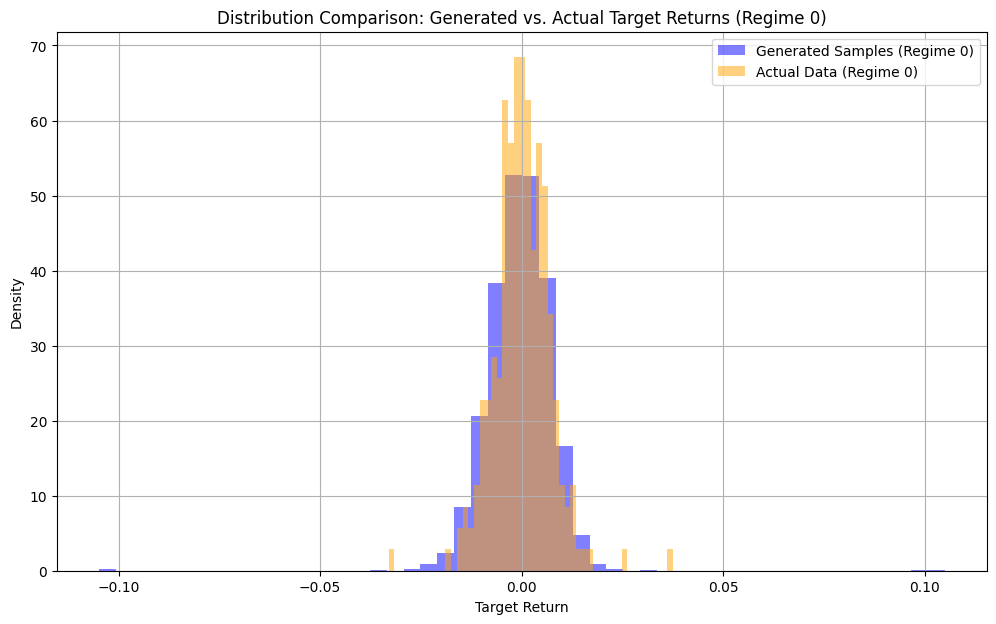

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
valid_generated_samples = generated_samples.flatten()
print(f"Number of generated samples: {len(valid_generated_samples)}")
print(f"Number of NaN values in generated samples: {np.isnan(valid_generated_samples).sum()}")
print(f"Number of infinite values in generated samples: {np.isinf(valid_generated_samples).sum()}")
valid_generated_samples = valid_generated_samples[np.isfinite(valid_generated_samples)]
actual_regime0_returns = condition_df[condition_df['regime'] == 0]['target_return'].dropna().values

print(f"\nNumber of actual regime 0 returns: {len(actual_regime0_returns)}")
print(f"Number of NaN values in actual regime 0 returns: {np.isnan(actual_regime0_returns).sum()}")
print(f"Number of infinite values in actual regime 0 returns: {np.isinf(actual_regime0_returns).sum()}")
actual_regime0_returns = actual_regime0_returns[np.isfinite(actual_regime0_returns)]

plt.figure(figsize=(12, 7))
if len(valid_generated_samples) > 0:
    plt.hist(valid_generated_samples, bins=50, density=True, alpha=0.5, label='Generated Samples (Regime 0)', color='blue')
    print("\nSummary statistics of generated samples:")
    print(pd.Series(valid_generated_samples).describe())
else:
    print("\nWarning: All generated samples are NaN or infinite. Check the model and sampling process.")
if len(actual_regime0_returns) > 0:
    plt.hist(actual_regime0_returns, bins=50, density=True, alpha=0.5, label='Actual Data (Regime 0)', color='orange')
    print("\nSummary statistics of actual regime 0 returns:")
    print(pd.Series(actual_regime0_returns).describe())
else:
    print("\nWarning: No valid actual regime 0 returns found.")

plt.title('Distribution Comparison: Generated vs. Actual Target Returns (Regime 0)')
plt.xlabel('Target Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#| default_exp VaR_ES

In [ ]:
#| export
from scipy import stats

def _pct_error(gen_val, act_val):
    """Signed percentage error, robust to near-zero denominators."""
    denom = abs(act_val) if abs(act_val) > 1e-8 else 1e-8
    return (gen_val - act_val) / denom * 100

def risk_comparison(generated_samples, actual_returns, confidence_levels=[0.95, 0.99]):
    gen = generated_samples.flatten()
    act = actual_returns.flatten()

    print(f"{'Metric':<25} {'Generated':>12} {'Actual':>12} {'Error%':>10}")
    print('-' * 62)

    for cl in confidence_levels:
        var_gen = np.percentile(gen, (1 - cl) * 100)
        var_act = np.percentile(act, (1 - cl) * 100)
        print(f"VaR  {cl:.0%}            {var_gen:>12.6f} {var_act:>12.6f} {_pct_error(var_gen, var_act):>9.1f}%")

        cvar_gen = gen[gen <= var_gen].mean()
        cvar_act = act[act <= var_act].mean()
        print(f"CVaR {cl:.0%}            {cvar_gen:>12.6f} {cvar_act:>12.6f} {_pct_error(cvar_gen, cvar_act):>9.1f}%")

    print()
    for p in [1, 5]:
        pg, pa = np.percentile(gen, p), np.percentile(act, p)
        print(f"{'%dth percentile' % p:<25} {pg:>12.6f} {pa:>12.6f} {_pct_error(pg, pa):>9.1f}%")

    print('\nTarget: VaR error < 10% = production grade, < 20% = acceptable')
actual_regime0_returns = condition_df[condition_df['regime'] == 0]['target_return'].dropna().values
risk_comparison(generated_samples, actual_regime0_returns)

Metric                       Generated       Actual     Error%
--------------------------------------------------------------
VaR  95%               -0.012695    -0.010442     -21.6%
CVaR 95%               -0.017487    -0.014863     -17.7%
VaR  99%               -0.018071    -0.015068     -19.9%
CVaR 99%               -0.028183    -0.022314     -26.3%

1th percentile               -0.018071    -0.015068     -19.9%
5th percentile               -0.012695    -0.010442     -21.6%

Target: VaR error < 10% = production grade, < 20% = acceptable


In [ ]:
actual_regime0_returns = condition_df[condition_df['regime'] == 0]['target_return'].dropna().values
risk_comparison(generated_samples, actual_regime0_returns)

Metric                       Generated       Actual     Error%
--------------------------------------------------------------
VaR  95%               -0.012695    -0.010442     -21.6%
CVaR 95%               -0.017487    -0.014863     -17.7%
VaR  99%               -0.018071    -0.015068     -19.9%
CVaR 99%               -0.028183    -0.022314     -26.3%

1th percentile               -0.018071    -0.015068     -19.9%
5th percentile               -0.012695    -0.010442     -21.6%

Target: VaR error < 10% = production grade, < 20% = acceptable
